In [38]:
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA

x = pd.read_csv('all_seasons.csv')  # Load your data from an Excel file
x

,Unnamed: 0,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12839,12839,Joel Embiid,PHI,29.0,213.36,127.005760,Kansas,Cameroon,2014,1,...,33.1,10.2,4.2,8.8,0.057,0.243,0.370,0.655,0.233,2022-23
12840,12840,John Butler Jr.,POR,20.0,213.36,86.182480,Florida State,USA,Undrafted,Undrafted,...,2.4,0.9,0.6,-16.1,0.012,0.065,0.102,0.411,0.066,2022-23
12841,12841,John Collins,ATL,25.0,205.74,102.511792,Wake Forest,USA,2017,1,...,13.1,6.5,1.2,-0.2,0.035,0.180,0.168,0.593,0.052,2022-23
12842,12842,Jericho Sims,NYK,24.0,208.28,113.398000,Texas,USA,2021,2,...,3.4,4.7,0.5,-6.7,0.117,0.175,0.074,0.780,0.044,2022-23


In [39]:
features1 = ["player_height", "player_weight"]

data1 = x[features1].copy()  # Separating out the features
data1



,player_height,player_weight
0,193.04,94.800728
1,190.50,86.182480
2,203.20,103.418976
3,203.20,102.058200
4,213.36,119.748288
...,...,...
12839,213.36,127.005760
12840,213.36,86.182480
12841,205.74,102.511792
12842,208.28,113.398000


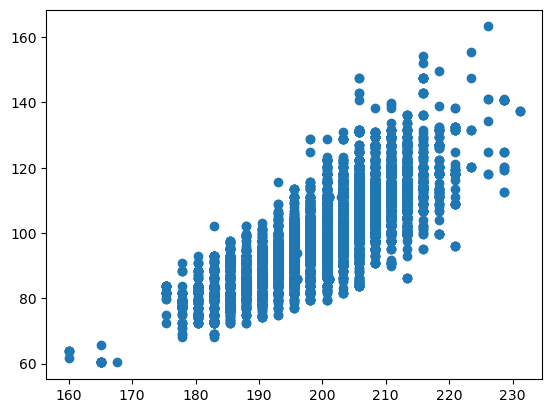

In [40]:
import matplotlib.pyplot as plt
plt.scatter(data1.iloc[:,0],data1.iloc[:,1])
plt.show()

In [41]:
pca1 = PCA(n_components=2)
pca_result1 = pca1.fit_transform(data1)

In [42]:
print('Matrix covarian')
print(pca1.get_covariance())

Matrix covarian
[[ 83.0119649   93.08293224]
 [ 93.08293224 154.42108543]]


In [44]:
print("Eigenvalue : ")
print(pca1.explained_variance_)

Eigenvalue : 
[218.4123019   19.02074843]


In [45]:
print("Eigenvector : ")
print(pca1.components_)


Eigenvector : 
[[ 0.56650899  0.82405556]
 [ 0.82405556 -0.56650899]]


In [46]:
print("Hasil Transformasi PCA 1")
print(pca_result1)

Hasil Transformasi PCA 1
[[ -8.75881543  -3.09827274]
 [-17.29966344  -0.30905891]
 [  4.09883107   0.3918168 ]
 ...
 [  4.79019388   2.99884581]
 [ 15.19996695  -1.07518774]
 [  5.16397889   2.74188187]]


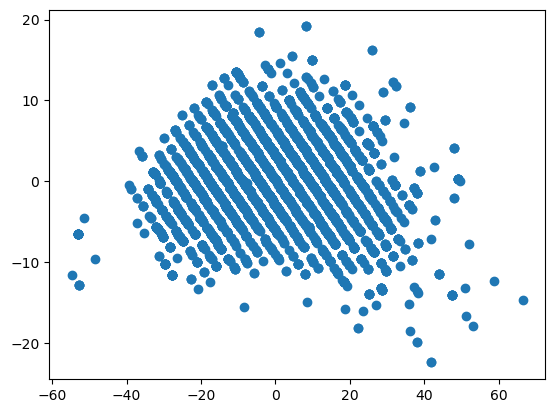

In [47]:
plt.scatter(pca_result1[:,0],pca_result1[:,1])
plt.show()

In [48]:
#Tahap 1, Variance Thrfeshold
variance1 = data1.var()
print("Variance : ",variance1.sort_values(ascending=False))

Variance :  player_weight    154.421085
player_height     83.011965
dtype: float64


In [49]:
#means
means1 = data1.mean()
print("Mean : ",means1.sort_values(ascending=False))

Mean :  player_height    200.555097
player_weight    100.263279
dtype: float64


In [50]:
#Tahap 2, Correlation Analysis
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
plt.figure(figsize=(12,8))

corr = data1.corr()
corr

,player_height,player_weight
player_height,1.000000,0.822141
player_weight,0.822141,1.000000


<Figure size 1200x800 with 0 Axes>

In [51]:
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(15)
selector.fit_transform(data1)

array([[193.04    ,  94.800728],
       [190.5     ,  86.18248 ],
       [203.2     , 103.418976],
       ...,
       [205.74    , 102.511792],
       [208.28    , 113.398   ],
       [205.74    , 102.965384]], shape=(12844, 2))

In [52]:
df_pca = pd.DataFrame(data = pca_result1, columns = ['PC1', 'PC2'])
print("Korelasi antar komponen")
print(df_pca.corr())

Korelasi antar komponen
              PC1           PC2
PC1  1.000000e+00 -8.798660e-13
PC2 -8.798660e-13  1.000000e+00


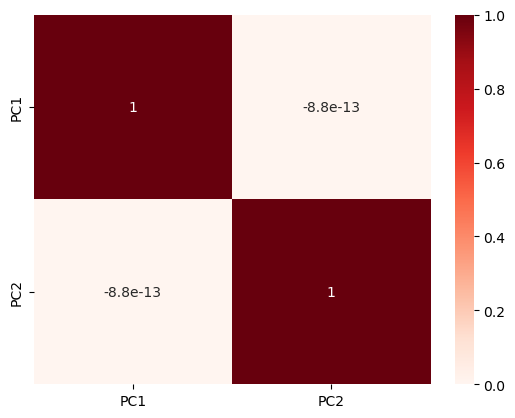

In [53]:
sns.heatmap(df_pca.corr(), annot=True, cmap=plt.cm.Reds)
plt.show()